# The Atoms Object

## Overview
**Questions**
- How can I describe a molecule or crystal using the `Atoms` class?
- How can I access and adjust `Atoms` information?
- What built-in help is available from ASE?
- How can I read in a molecule or crystal from a database or external programme?

**Objectives**
- Create and visualise an `Atoms` object
- Use `ase.build` to construct common crystal structures
- Return simple structural information from an `Atoms` object
- Adjust default properties of an `Atoms` object
- Read in a CIF file 

**Keypoints**
- Molecules and materials are represented by the `Atoms` class
- Periodic boundary conditions are used to simulate an infinitely large system: crystals require `cell` (unit cell) and `pbc` (periodic boundary conditions)
- Getter methods (`get_positions()`, `get_masses()`, ...) retrieve information
- Setter methods (`set_cell()`, `set_initial_magnetic_moments()`, ...) modify the object
- `ase.io.read` and `ase.io.write` handle 50+ file formats

## Lecture Slides

The slides for this tutorial are embedded below.
[📥 Download slides (.pptx)](https://github.com/NU-CEM/Atomistic_Simulation/raw/2026/slides/Tutorial2_MaterialsBasics.pptx) &nbsp;|&nbsp; [Open in full screen](https://livenorthumbriaac-my.sharepoint.com/personal/l_whalley_northumbria_ac_uk/_layouts/15/Doc.aspx?sourcedoc={2010c6a1-e250-4d00-8172-c30d27736729}&amp;action=embedview&amp;wdAr=1.7777777777777777)

<iframe
  src="https://livenorthumbriaac-my.sharepoint.com/personal/l_whalley_northumbria_ac_uk/_layouts/15/Doc.aspx?sourcedoc={2010c6a1-e250-4d00-8172-c30d27736729}&amp;action=embedview&amp;wdAr=1.7777777777777777"
  width="100%"
  height="480"
  frameborder="0"
  allowfullscreen="true">
</iframe>

## Molecules and materials are represented by the `Atoms` class

The `Atoms` class is the central data structure in ASE. It holds:
- **Chemical symbols** (or atomic numbers) of each atom
- **Positions** of each atom (in Ångströms)
- Optionally: the **unit cell**, **periodic boundary conditions**, **momenta**, **charges**, **magnetic moments**, ...

To use the `Atoms` class we need to import it from the `ase` library:

In [1]:
from ase import Atoms

### Creating a simple isolated molecule

We can define a diatomic (two-atom) molecule by providing lists of symbols and Cartesian positions. Below we assign the `Atoms` object to the variable `N2_molecule` (we could have called it anything, but your variable names should always be descriptive).

In [2]:
# N2 molecule
d = 1.10  # N-N bond length in Angstrom
N2_molecule = Atoms(['N', 'N'], positions=[(0., 0., 0.), (0., 0., d)])

Alternatively, we can provide a chemical formula as a string

In [3]:
# Shorthand: chemical formula string
N2_molecule = Atoms('N2', positions=[(0., 0., 0.), (0., 0., d)])

Once we have created the `Atoms` object we can get stored information:

In [4]:
print(f"Formula: {N2_molecule.get_chemical_formula()}")
print(f"Number of atoms: {len(N2_molecule)}")

Formula: N2
Number of atoms: 2


### Visualising an `Atoms` object

We can use `ase.visualize.view` with the `nglview` backend to display structures inline in a Jupyter notebook.

This will display an interactive 3D view in a Jupyter notebook: Left-click-and-drag to rotate; scroll to zoom.

In [5]:
from ase.visualize import view

view(N2_molecule, viewer='ngl')

If `nglview` is not installed then we can use `matplotlib` and `ase` to produce a non-interative display

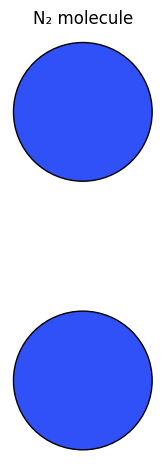

In [6]:
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

fig, ax = plt.subplots()
plot_atoms(N2_molecule, ax, show_unit_cell = 2, radii=0.2, rotation=('30x,0y,0z'))
ax.set_title('N₂ molecule')
ax.axis('off')
plt.tight_layout()
plt.show()

The key function in the code block above is `plot_atoms`. To understand what optional arguments can be used you can access the in-built help using `?`:

In [7]:
plot_atoms?

Signature: plot_atoms(atoms: 'Atoms', ax: 'Axes | None' = None, **kwargs) -> 'Axes'
Docstring:
Plot an Atoms object in a matplotlib subplot.

Axis decorations will always be removed.

For finer control of plot appearance or composition of custom plot
arrangements, consider using plot_atoms_raw() to plot directly to given
Matplotlib Axes.

Parameters
----------
atoms : Atoms object
ax : Matplotlib subplot object
rotation : str, optional
    In degrees. In the form '10x,20y,30z'
show_unit_cell : int, optional, default 2
    Draw the unit cell as dashed lines depending on value:
    0: Don't
    1: Do
    2: Do, making sure cell is visible
radii : float, optional
    The radii of the atoms
colors : list of strings, optional
    Color of the atoms, must be the same length as
    the number of atoms in the atoms object.
scale : float, optional
    Scaling of the plotted atoms and lines.
offset : tuple (float, float), optional
    Offset of the plotted atoms and lines.
File:      ~/miniconda

## Describing crystals: `cell` and `pbc`

Crystals are described by atomic positions inside a **periodic unit cell**. Two key keywords:
- `cell` — the unit cell vectors (3×3 matrix, or 3 lengths for cubic cells)
- `pbc` — periodic boundary conditions (True/False per direction)

The atomic positions can be specified as an absolute position (`positions`), or as a fractional position in the unit cell (`scaled_positions`).

### Example: Zinc blende GaN

GaN is a wide-bandgap semiconductor widely used in blue LEDs and increasingly explored as a host for single photon emitters. Here we construct the zinc blende polymorph.

In [8]:
import numpy as np
from ase import Atoms

# Zinc blende GaN: a = 4.50 Angstrom
a = 4.50
gan = Atoms('Ga4N4',
            scaled_positions=[
                [0.00, 0.00, 0.00],  # Ga
                [0.00, 0.50, 0.50],  # Ga
                [0.50, 0.00, 0.50],  # Ga
                [0.50, 0.50, 0.00],  # Ga
                [0.25, 0.25, 0.25],  # N
                [0.25, 0.75, 0.75],  # N
                [0.75, 0.25, 0.75],  # N
                [0.75, 0.75, 0.25],  # N
            ],
            cell=[a, a, a],
            pbc=True)

print(f"Formula: {gan.get_chemical_formula()}")
print(f"Number of atoms: {len(gan)}")
print(f"Unit cell (Å):\n{gan.cell}")


Formula: Ga4N4
Number of atoms: 8
Unit cell (Å):
Cell([4.5, 4.5, 4.5])


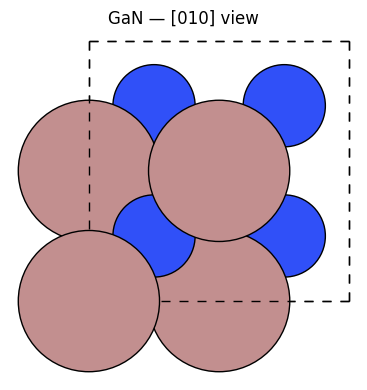

In [9]:
# Visualise the GaN crystal
from ase.visualize.plot import plot_atoms

fig, axes = plt.subplots(1, 1, figsize=(10, 4))

plot_atoms(gan, axes, rotation=('0x,90y,0z'))
axes.set_title('GaN — [010] view')
axes.axis('off')
plt.tight_layout()
plt.show()


## `ase.build` — tools for constructing structures

ASE also provides set of structure-building utilities in `ase.build`. These are particularly useful for constructing more complex structures such as surfaces.
| Function | Purpose |
|----------|---------|
| `bulk` | Common crystal structures (FCC, BCC, diamond, wurtzite, ...) |
| `molecule` | Molecules from the G2 database |
| `surface` | Cut surfaces from a bulk structure |
| `make_supercell` | Create a supercell with an arbitrary transformation matrix |

In [2]:
from ase.build import bulk

diamond_C  = bulk('C',   'diamond',  a=3.57)
zincblende_GaN = bulk('GaN', 'zincblende', a=4.50)
rocksalt_MgO = bulk('MgO', 'rocksalt', a=4.21)

for name, atoms in [('Diamond C', diamond_C),
                    ('Zincblende GaN', zincblende_GaN),
                    ('Rocksalt MgO', rocksalt_MgO)]:
    print(f"{name}: {atoms.get_chemical_formula()} "
          f"({len(atoms)} atoms, volume = {atoms.get_volume():.2f} Å³)")

Diamond C: C2 (2 atoms, volume = 11.37 Å³)
Zincblende GaN: GaN (2 atoms, volume = 22.78 Å³)
Rocksalt MgO: MgO (2 atoms, volume = 18.65 Å³)


## Getter methods

Remember, once we have an `Atoms` object, we can retrieve information using **getter** methods:


In [10]:
print("Positions (Å):")
print(gan.get_positions())

print("\nChemical symbols:")
print(gan.get_chemical_symbols())

print("\nAtomic masses (u):")
print(gan.get_masses())

print("\nCell volume (Å³):", gan.get_volume())

Positions (Å):
[[0.    0.    0.   ]
 [0.    2.25  2.25 ]
 [2.25  0.    2.25 ]
 [2.25  2.25  0.   ]
 [1.125 1.125 1.125]
 [1.125 3.375 3.375]
 [3.375 1.125 3.375]
 [3.375 3.375 1.125]]

Chemical symbols:
['Ga', 'Ga', 'Ga', 'Ga', 'N', 'N', 'N', 'N']

Atomic masses (u):
[69.723 69.723 69.723 69.723 14.007 14.007 14.007 14.007]

Cell volume (Å³): 91.12499999999999


The positions, chemical symbols and atomic masses are returned as numpy arrays. 

In [12]:
print(type(gan.get_positions()))

<class 'numpy.ndarray'>


This means that if we want to return e.g. the position of the first three atoms we can use array slicing:

In [13]:

print(gan.get_positions()[:2])

[[0.   0.   0.  ]
 [0.   2.25 2.25]]


## Setter methods

We can modify an `Atoms` object after creation using **setter** methods. These methods will overwrite the original settings, so if you want to keep the original object you must create an object first:

In [14]:
# Copy the structure and apply a small strain
import copy
strained = gan.copy()

# Biaxial strain in x-y plane (e.g. from epitaxial growth on a substrate)
cell = strained.get_cell()
strain = 0.02  # 2% tensile strain
cell[0] *= (1 + strain)
cell[1] *= (1 + strain)
strained.set_cell(cell, scale_atoms=True)

print(f"Original lattice constant: {gan.cell[0,0]:.4f} Å")
print(f"Strained lattice constant: {strained.cell[0,0]:.4f} Å")

# Magnetic moments — relevant for spin-based quantum systems
gan.set_initial_magnetic_moments([0.0] * len(gan))
print(f"\nInitial magnetic moments: {gan.get_initial_magnetic_moments()}")

Original lattice constant: 4.5000 Å
Strained lattice constant: 4.5900 Å

Initial magnetic moments: [0. 0. 0. 0. 0. 0. 0. 0.]


## Exercise 2.1

Construct a wurtzite GaN unit cell (the more common hexagonal polymorph). It has:
- Lattice parameters: a = 3.19 Å, c = 5.19 Å
- hexagonal cell matrix: \begin{pmatrix}
a & 0 & 0 \\
-\frac{a}{2} & \frac{a\sqrt{3}}{2} & 0 \\
0 & 0 & c
\end{pmatrix}
- Scaled positions: Ga at (1/3, 2/3, 0) and (2/3, 1/3, 1/2); N at (1/3, 2/3, 3/8) and (2/3, 1/3, 7/8)

Use `ase.build.bulk('GaN', crystalstructure='wurtzite', a=3.19, c=5.19)` to check your answer.

## Exercise 2.2

The NV centre in diamond consists of a nitrogen substitutional adjacent to a carbon vacancy. Build a diamond cubic unit cell (a = 3.57 Å, 8 atoms) and print the nearest-neighbour C-C bond length. Compare to the known value of 1.54 Å.

For this question you need to find the atomic positions in the diamond structure, and may want to use the `ASE` documentation to find a function for finding nearest neighbour distances.


## Writing and Reading structures with `ase.io.read`

ASE can read and write over 50 crystal structure file formats. 

The primary function to read in structures is `ase.io.read`, which auto-detects the format from the file extension.

Common formats you might encounter:

| Format | Extension | Used by |
|--------|-----------|---------|
| CIF | `.cif` | Crystallographic databases (ICSD, Materials Project) |
| XYZ | `.xyz` | General|
| extXYZ | `.xyz` | many ML codes |
| Trajectory | `.traj` | ASE native format |


### Build a structure using ASE's build module

In [22]:
import ase.io
from ase.io import read, write
from ase import Atoms
import numpy as np

from ase.build import bulk

gan_wz = bulk('GaN', crystalstructure='wurtzite', a=3.19, c=5.19)
print(f"Wurtzite GaN: {len(gan_wz)} atoms, formula {gan_wz.get_chemical_formula()}")
print(f"Cell (Å):\n{gan_wz.cell}\n")    # \n creates newlines for neater display

Wurtzite GaN: 4 atoms, formula Ga2N2
Cell (Å):
Cell([[3.19, 0.0, 0.0], [-1.595, 2.7626210380723593, 0.0], [0.0, 0.0, 5.19]])



### Writing to different formats

In [17]:
import os

# Write to XYZ (a widely used file format)
write('/tmp/GaN_wurtzite.xyz', gan_wz)

# Write to CIF (another widely used file format(
write('/tmp/GaN_wurtzite.cif', gan_wz, format='cif')

### Inspecting file content

The extended XYZ format is particularly useful because it stores cell and PBC information in the header line:

In [23]:
with open('/tmp/GaN_wurtzite.xyz') as f:
    print(f.read())

4
Lattice="3.19 0.0 0.0 -1.595 2.7626210380723593 0.0 0.0 0.0 5.19" Properties=species:S:1:pos:R:3 pbc="T T T"
Ga       0.00000000       0.00000000       0.00000000
N       -0.00000000       1.84174736       0.64392903
Ga      -0.00000000       1.84174736       2.59500000
N        0.00000000       0.00000000       3.23892903



Inspecting the cif file shows that it stores the same information in a slightly different format:

In [24]:
with open('/tmp/GaN_wurtzite.cif') as f:
    print(f.read())

data_image0
_chemical_formula_structural       GaNGaN
_chemical_formula_sum              "Ga2 N2"
_cell_length_a       3.19
_cell_length_b       3.19
_cell_length_c       5.19
_cell_angle_alpha    90.0
_cell_angle_beta     90.0
_cell_angle_gamma    120.00000000000001

_space_group_name_H-M_alt    "P 1"
_space_group_IT_number       1

loop_
  _space_group_symop_operation_xyz
  'x, y, z'

loop_
  _atom_site_type_symbol
  _atom_site_label
  _atom_site_symmetry_multiplicity
  _atom_site_fract_x
  _atom_site_fract_y
  _atom_site_fract_z
  _atom_site_occupancy
  Ga  Ga1       1.0  0.0  0.0  0.0  1.0000
  N   N1        1.0  0.3333333333333333  0.6666666666666666  0.12407110408213018  1.0000
  Ga  Ga2       1.0  0.3333333333333333  0.6666666666666666  0.5  1.0000
  N   N2        1.0  0.0  0.0  0.6240711040821302  1.0000



Read back in the XYZ file and show that it matches the positions

In [25]:
gan_readback = read('/tmp/GaN_wurtzite.xyz')
print("Read back from XYZ:")
print(f"  Formula: {gan_readback.get_chemical_formula()}")
print(f"  Positions match: {np.allclose(gan_wz.positions, gan_readback.positions)}")

Read back from XYZ:
  Formula: Ga2N2
  Positions match: True


## Exercise 2.3

Download the CIF file for hexagonal boron nitride (hBN) from the The [Materials Project](https://materialsproject.org). Read it with ASE and print the lattice parameters and number of atoms in the unit cell.